# Decision Tree Lab

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split as tts
import matplotlib.pyplot as plt
import graphviz 

from sklearn.model_selection import GridSearchCV,RepeatedStratifiedKFold
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz 

### Steps 1-4: cleaning and prep

In [2]:
movie_metadata=pd.read_csv("/workspaces/DS-3021/data/movie_metadata.csv")

In [5]:
movie_metadata['content_rating'].unique()

array(['PG-13', nan, 'PG', 'G', 'R', 'TV-14', 'TV-PG', 'TV-MA', 'TV-G',
       'Not Rated', 'Unrated', 'Approved', 'TV-Y', 'NC-17', 'X', 'TV-Y7',
       'GP', 'Passed', 'M'], dtype=object)

In [19]:
def movie_cleaning(data):
    movies = data[['duration', 'genres', 'gross', 'content_rating', 'budget', 'cast_total_facebook_likes', 'imdb_score']]
    genres = ['Action', 'Drama', 'Comedy', 'Romance', 'Horror', 'Thriller', 
              'Adventure', 'Fantasy', 'Sci-Fi', 'Animation', 'Documentary', 
              'Family', 'Mystery', 'Western', 'Crime', 'Music', 'War', 'History', 
              'Sport', 'Short', 'Biography']
    for genre in genres:
        movies[genre] = 0
    for index, row in movies.iterrows():
        for genre in genres:
            if genre in row['genres']:
                movies.loc[index, genre] = 1
    movies = movies.drop(columns=['genres'])
    movies = movies.dropna()
    movies = movies[movies['budget'] < 3500000000]
    movies = movies[movies['cast_total_facebook_likes'] < 320000]
    movies['imdb_score'] = movies['imdb_score'].apply(lambda x: '1' if x >= 7.5 else '0')
    movies['imdb_score'] = movies['imdb_score'].astype(int)
    movies_encoded = pd.get_dummies(movies, columns=['content_rating']) 
    return movies_encoded 

pd.options.mode.chained_assignment = None  # default='warn'
movs = movie_cleaning(movie_metadata)
movs

,duration,gross,budget,cast_total_facebook_likes,imdb_score,Action,Drama,Comedy,Romance,Horror,...,content_rating_GP,content_rating_M,content_rating_NC-17,content_rating_Not Rated,content_rating_PG,content_rating_PG-13,content_rating_Passed,content_rating_R,content_rating_Unrated,content_rating_X
0,178.0,760505847.0,237000000.0,4834,1,1,0,0,0,0,...,False,False,False,False,False,True,False,False,False,False
1,169.0,309404152.0,300000000.0,48350,0,1,0,0,0,0,...,False,False,False,False,False,True,False,False,False,False
2,148.0,200074175.0,245000000.0,11700,0,1,0,0,0,0,...,False,False,False,False,False,True,False,False,False,False
3,164.0,448130642.0,250000000.0,106759,1,1,0,0,0,0,...,False,False,False,False,False,True,False,False,False,False
5,132.0,73058679.0,263700000.0,1873,0,1,0,0,0,0,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5033,77.0,424760.0,7000.0,368,0,0,1,0,0,0,...,False,False,False,False,False,True,False,False,False,False
5034,80.0,70071.0,7000.0,0,0,0,0,0,0,0,...,False,False,False,True,False,False,False,False,False,False
5035,81.0,2040920.0,7000.0,147,0,1,1,0,1,0,...,False,False,False,False,False,False,False,True,False,False
5037,95.0,4584.0,9000.0,690,0,0,1,1,0,0,...,False,False,False,True,False,False,False,False,False,False


In [20]:
#I want to check out which genres there are the most few of.
for genre in ['Action', 'Drama', 'Comedy', 'Romance', 'Horror', 'Thriller', 
              'Adventure', 'Fantasy', 'Sci-Fi', 'Animation', 'Documentary', 
              'Family', 'Mystery', 'Western', 'Crime', 'Music', 'War', 'History', 
              'Sport', 'Short', 'Biography']:
    print(genre, movs[genre].value_counts(normalize=True) * 100)

#many of them have very small prevalences, so I will drop them.
smallprevs = ['Short', 'Documentary', 'War', 'History', 'Biography', 'Music', 'Western', 'Sport', 'Animation']
movs = movs.drop(columns=smallprevs)
movs


Action Action
0    74.850143
1    25.149857
Name: proportion, dtype: float64
Drama Drama
1    50.430023
0    49.569977
Name: proportion, dtype: float64
Comedy Comedy
0    61.167579
1    38.832421
Name: proportion, dtype: float64
Romance Romance
0    77.169664
1    22.830336
Name: proportion, dtype: float64
Horror Horror
0    89.757623
1    10.242377
Name: proportion, dtype: float64
Thriller Thriller
0    70.706281
1    29.293719
Name: proportion, dtype: float64
Adventure Adventure
0    79.410998
1    20.589002
Name: proportion, dtype: float64
Fantasy Fantasy
0    86.63018
1    13.36982
Name: proportion, dtype: float64
Sci-Fi Sci-Fi
0    87.02111
1    12.97889
Name: proportion, dtype: float64
Animation Animation
0    94.839719
1     5.160281
Name: proportion, dtype: float64
Documentary Documentary
0    98.566588
1     1.433412
Name: proportion, dtype: float64
Family Family
0    88.29815
1    11.70185
Name: proportion, dtype: float64
Mystery Mystery
0    89.861871
1    10.138129
Name: pr

,duration,gross,budget,cast_total_facebook_likes,imdb_score,Action,Drama,Comedy,Romance,Horror,...,content_rating_GP,content_rating_M,content_rating_NC-17,content_rating_Not Rated,content_rating_PG,content_rating_PG-13,content_rating_Passed,content_rating_R,content_rating_Unrated,content_rating_X
0,178.0,760505847.0,237000000.0,4834,1,1,0,0,0,0,...,False,False,False,False,False,True,False,False,False,False
1,169.0,309404152.0,300000000.0,48350,0,1,0,0,0,0,...,False,False,False,False,False,True,False,False,False,False
2,148.0,200074175.0,245000000.0,11700,0,1,0,0,0,0,...,False,False,False,False,False,True,False,False,False,False
3,164.0,448130642.0,250000000.0,106759,1,1,0,0,0,0,...,False,False,False,False,False,True,False,False,False,False
5,132.0,73058679.0,263700000.0,1873,0,1,0,0,0,0,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5033,77.0,424760.0,7000.0,368,0,0,1,0,0,0,...,False,False,False,False,False,True,False,False,False,False
5034,80.0,70071.0,7000.0,0,0,0,0,0,0,0,...,False,False,False,True,False,False,False,False,False,False
5035,81.0,2040920.0,7000.0,147,0,1,1,0,1,0,...,False,False,False,False,False,False,False,True,False,False
5037,95.0,4584.0,9000.0,690,0,0,1,1,0,0,...,False,False,False,True,False,False,False,False,False,False


In [21]:
#I want to check out which content ratings there are the most few of.
content_rating_columns = [col for col in movs.columns if 'content_rating' in col]
# Iterate over those columns and calculate percentages
for rating in content_rating_columns:
    print(rating, movs[rating].value_counts(normalize=True) * 100)

#many of them have very small prevalences, so I will drop them.
smallprevs = ['content_rating_Approved', 'content_rating_G', 'content_rating_GP', 'content_rating_M',
              'content_rating_NC-17', 'content_rating_Passed', 'content_rating_Unrated', 'content_rating_X', 
              'content_rating_Not Rated']
movs = movs.drop(columns=smallprevs)
movs

content_rating_Approved content_rating_Approved
False    99.556946
True      0.443054
Name: proportion, dtype: float64
content_rating_G content_rating_G
False    97.628355
True      2.371645
Name: proportion, dtype: float64
content_rating_GP content_rating_GP
False    99.973938
True      0.026062
Name: proportion, dtype: float64
content_rating_M content_rating_M
False    99.947876
True      0.052124
Name: proportion, dtype: float64
content_rating_NC-17 content_rating_NC-17
False    99.843628
True      0.156372
Name: proportion, dtype: float64
content_rating_Not Rated content_rating_Not Rated
False    98.905395
True      1.094605
Name: proportion, dtype: float64
content_rating_PG content_rating_PG
False    84.988272
True     15.011728
Name: proportion, dtype: float64
content_rating_PG-13 content_rating_PG-13
False    65.337503
True     34.662497
Name: proportion, dtype: float64
content_rating_Passed content_rating_Passed
False    99.921814
True      0.078186
Name: proportion, dtype: flo

,duration,gross,budget,cast_total_facebook_likes,imdb_score,Action,Drama,Comedy,Romance,Horror,Thriller,Adventure,Fantasy,Sci-Fi,Family,Mystery,Crime,content_rating_PG,content_rating_PG-13,content_rating_R
0,178.0,760505847.0,237000000.0,4834,1,1,0,0,0,0,0,1,1,1,0,0,0,False,True,False
1,169.0,309404152.0,300000000.0,48350,0,1,0,0,0,0,0,1,1,0,0,0,0,False,True,False
2,148.0,200074175.0,245000000.0,11700,0,1,0,0,0,0,1,1,0,0,0,0,0,False,True,False
3,164.0,448130642.0,250000000.0,106759,1,1,0,0,0,0,1,0,0,0,0,0,0,False,True,False
5,132.0,73058679.0,263700000.0,1873,0,1,0,0,0,0,0,1,0,1,0,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5033,77.0,424760.0,7000.0,368,0,0,1,0,0,0,1,0,0,1,0,0,0,False,True,False
5034,80.0,70071.0,7000.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,False,False,False
5035,81.0,2040920.0,7000.0,147,0,1,1,0,1,0,1,0,0,0,0,0,1,False,False,True
5037,95.0,4584.0,9000.0,690,0,0,1,1,0,0,0,0,0,0,0,0,0,False,False,False


### Step 5: Prevalence

In [22]:
total_rows = movs.shape[0]
excellents = movs[movs['imdb_score'] == 1].shape[0]

pervalent_excellent = (excellents / total_rows) 
print(f"Prevalence of excellent movies: {pervalent_excellent}")

Prevalence of excellent movies: 0.1673182173573104


This means about 16% of the movies in our data set are classified as excellent per the imdb score. This is important because it gives us a baseline to compare our model's performance against. 

### Step 6: Split the data

In [23]:
X = movs.drop(columns=['imdb_score'])
y = movs['imdb_score']

X_train, X_test, y_train, y_test = tts(X, y, test_size=0.2, random_state=42)
X_test, X_tune, y_test, y_tune = tts(X_test, y_test, test_size=0.5, random_state=42)


### Step 7: Create the kfold object for cross validation.

In [24]:
kf = RepeatedStratifiedKFold(n_splits=10,n_repeats =5, random_state=42)

### Step 8: Create the scoring metric you will use to evaluate your model and the max depth hyperparameter (grid search) 

In [25]:
scoring = ['roc_auc','recall','balanced_accuracy']

param={"max_depth" : [1,2,3,4,5,6,7,8,9,10,11]}

### Step 9: Build the classifier object 

In [26]:
cl= DecisionTreeClassifier(random_state=1000)

### Step 10: Use the kfold object and the scoring metric to find the best hyperparameter value for max depth via the grid search method.

In [27]:
search = GridSearchCV(cl, param, scoring=scoring, n_jobs=-1, cv=kf,refit='roc_auc', verbose=3)

### Step 11: Fit the model to the training data

In [28]:
model = search.fit(X_train, y_train)


Fitting 50 folds for each of 11 candidates, totalling 550 fits
[CV 4/50] END max_depth=1; balanced_accuracy: (test=0.500) recall: (test=0.000) roc_auc: (test=0.696) total time=   0.1s[CV 10/50] END max_depth=1; balanced_accuracy: (test=0.500) recall: (test=0.000) roc_auc: (test=0.705) total time=   0.1s[CV 8/50] END max_depth=1; balanced_accuracy: (test=0.540) recall: (test=0.132) roc_auc: (test=0.540) total time=   0.1s

[CV 5/50] END max_depth=1; balanced_accuracy: (test=0.500) recall: (test=0.000) roc_auc: (test=0.624) total time=   0.1s
[CV 3/50] END max_depth=1; balanced_accuracy: (test=0.500) recall: (test=0.000) roc_auc: (test=0.618) total time=   0.1s
[CV 11/50] END max_depth=1; balanced_accuracy: (test=0.500) recall: (test=0.000) roc_auc: (test=0.683) total time=   0.1s
[CV 12/50] END max_depth=1; balanced_accuracy: (test=0.500) recall: (test=0.000) roc_auc: (test=0.616) total time=   0.1s
[CV 6/50] END max_depth=1; balanced_accuracy: (test=0.500) recall: (test=0.000) roc_auc:

### Step 12: What is the best depth value?

In [29]:
best = search.best_estimator_
print("Best parameters found: ", search.best_params_)
#best depth value is 6!

Best parameters found:  {'max_depth': 6}


### Step 13: print out the model

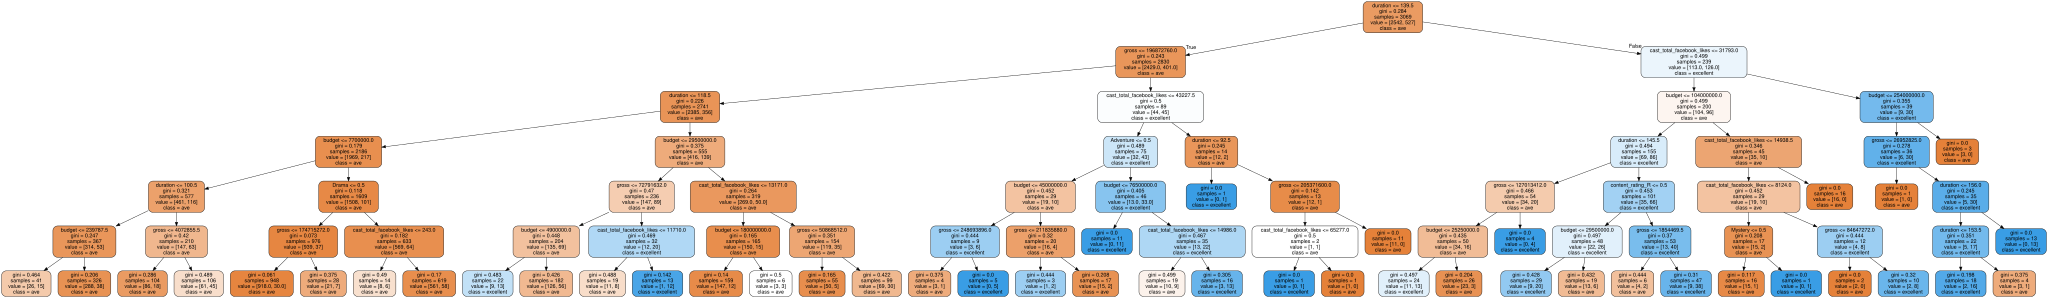

In [30]:
dot_data = export_graphviz(best, out_file =None,
               feature_names =X.columns, #feature names from dataset
               filled=True, 
                rounded=True, 
                class_names = ['ave','excellent']) #classification labels 
               
graph=graphviz.Source(dot_data)
graph

### Step 14: View the results, comment on how the model performed using the metrics you selected.

In [31]:
#picking relevant information out of all the metrics it has from the cross-validation
auc = model.cv_results_['mean_test_roc_auc']
recall= model.cv_results_['mean_test_recall']
bal_acc= model.cv_results_['mean_test_balanced_accuracy']

SDauc = model.cv_results_['std_test_roc_auc']
SDrecall= model.cv_results_['std_test_recall']
SDbal_acc= model.cv_results_['std_test_balanced_accuracy']

#Parameter:
depth= np.unique(model.cv_results_['param_max_depth']).data

#Results of different depths as a dataframe:
final_model = pd.DataFrame(list(zip(depth, auc, recall, bal_acc,SDauc,SDrecall,SDbal_acc)),
               columns =['depth','auc','recall','bal_acc','aucSD','recallSD','bal_accSD'])


final_model.style.hide(axis='index')

depth,auc,recall,bal_acc,aucSD,recallSD,bal_accSD
1,0.611574,0.076147,0.528555,0.040917,0.104720,0.040630
2,0.640703,0.197496,0.579512,0.043244,0.092156,0.040072
3,0.696541,0.157489,0.563089,0.038921,0.083263,0.035058
4,0.735909,0.175000,0.571015,0.034982,0.081520,0.035378
5,0.738075,0.214499,0.583448,0.035630,0.072990,0.032966
6,0.742966,0.232213,0.591754,0.038410,0.072076,0.034607
7,0.726241,0.269086,0.605116,0.038984,0.067406,0.031763
8,0.713535,0.308940,0.619497,0.038846,0.080855,0.038792
9,0.681979,0.322700,0.622520,0.043394,0.074997,0.035539
10,0.668092,0.347279,0.630403,0.040532,0.079044,0.037654


The biggest thing that stands out to me from these results is that the recall averages around 0.2, meaning that the model isn't very good at identifying excellent movies. The one promising thing is at the ideal depth length of 6, the AUC is 0.74. This suggests that the model is at least better than random guessing.

### Step 15 Which variables appear to be contributing the most (variable importance) 

In [92]:
varimp=pd.DataFrame(best.feature_importances_,index = X.columns,columns=['importance']).sort_values('importance', ascending=False)
print(varimp)

                           importance
duration                     0.334979
gross                        0.218116
budget                       0.191024
cast_total_facebook_likes    0.110380
country_USA                  0.044012
...                               ...
content_rating_Not Rated     0.000000
content_rating_PG-13         0.000000
content_rating_Passed        0.000000
content_rating_Unrated       0.000000
content_rating_X             0.000000

[83 rows x 1 columns]


Duration seems to be contributing the most! It also looks like there are many variables (notably the genres and countries) not contributing at all!

### Steps 16, 17, and 18: Use the predict method on the tune data and print out the results. How did the model perform on the tune data?

In [93]:
y_pred = model.predict(X_tune)
print(y_pred)

[0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0
 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0]


In [94]:
TPR = metrics.recall_score(y_tune, model.predict(X_tune))
print("True Positive Rate: ",TPR)
Prec = metrics.precision_score(y_tune, model.predict(X_tune))
print("Precision: ",Prec)
# the precision isn't very good!
Accuracy = metrics.accuracy_score(y_tune, model.predict(X_tune))
print("Accuracy: ",Accuracy)

True Positive Rate:  0.18032786885245902
Precision:  0.39285714285714285
Accuracy:  0.8255208333333334


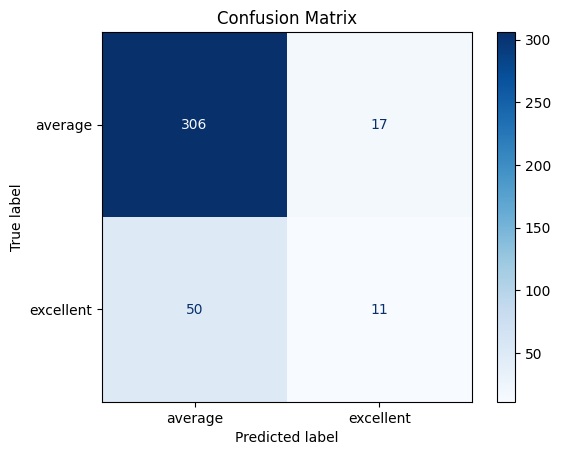

In [95]:
#To evaluate, lets make a confustion matrix
cm = metrics.confusion_matrix(y_tune, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= ['average', 'excellent'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

Unsurprisingly, the model did well at correctly identifying movies that were average, because the low prevalence of excellent movies means most all of the movies are considered average. The model did not do well at identifying excellent movies, catching less than 20 percent of them. Depending on the goal, this could be a really big problem.

### Step 19: What are the top 3 movies based on the tune set? Which variables are most important in predicting the top 3 movies?

In [96]:
probs = best.predict_proba(X_tune)
indices = X_tune.index
probs = pd.DataFrame(probs, columns=['average', 'excellent'], index=indices)
probs = probs.sort_values(by='excellent', ascending=False)
probs

,average,excellent
604,0.0,1.0
523,0.0,1.0
1867,0.0,1.0
326,0.0,1.0
3024,0.0,1.0
...,...,...
113,1.0,0.0
1124,1.0,0.0
31,1.0,0.0
211,1.0,0.0


In [97]:
#since I didn't change the indices during data cleaning, I can look up the movies
#titles in the original dataset using the indices
for i in [604, 523, 1867]:
    print(movie_metadata.loc[i]['movie_title'])

#War Horse, The Lost World: Jurassic Park, and Mrs Doubtfire are the top 3 movies

War Horse 
The Lost World: Jurassic Park 
Mrs. Doubtfire 


In [ ]:
# Determine feature importances
feature_importances = model.best_estimator_.feature_importances_
features = X.columns

# Create a DataFrame for feature importances
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df.head(3))
# the most important features in predicting the top 3 movies 
# are duration, gross, and budget

    Feature  Importance
0  duration    0.334979
1     gross    0.218116
2    budget    0.191024


### Steps 20 and 21: Use a different hyperparameter for the grid search function and go through the process above again using the tune set. Did the model perform better or worse?

In [60]:
scoring = ['roc_auc','recall','balanced_accuracy']
new_param = {"max_leaf_nodes":[10,20,30,40,50,60]}
cl = DecisionTreeClassifier(random_state=1000)
search = GridSearchCV(cl, new_param, scoring=scoring, n_jobs=-1, cv=kf,refit='roc_auc', verbose=3)

In [64]:
model = search.fit(X_train, y_train)
best_nodes = search.best_estimator_

Fitting 50 folds for each of 6 candidates, totalling 300 fits


[CV 3/50] END max_leaf_nodes=10; balanced_accuracy: (test=0.635) recall: (test=0.321) roc_auc: (test=0.745) total time=   0.1s
[CV 7/50] END max_leaf_nodes=10; balanced_accuracy: (test=0.527) recall: (test=0.094) roc_auc: (test=0.691) total time=   0.1s
[CV 2/50] END max_leaf_nodes=10; balanced_accuracy: (test=0.569) recall: (test=0.212) roc_auc: (test=0.751) total time=   0.1s
[CV 4/50] END max_leaf_nodes=10; balanced_accuracy: (test=0.609) recall: (test=0.245) roc_auc: (test=0.738) total time=   0.1s
[CV 6/50] END max_leaf_nodes=10; balanced_accuracy: (test=0.515) recall: (test=0.057) roc_auc: (test=0.712) total time=   0.1s
[CV 5/50] END max_leaf_nodes=10; balanced_accuracy: (test=0.540) recall: (test=0.132) roc_auc: (test=0.698) total time=   0.1s
[CV 1/50] END max_leaf_nodes=10; balanced_accuracy: (test=0.626) recall: (test=0.308) roc_auc: (test=0.717) total time=   0.1s
[CV 9/50] END max_leaf_nodes=10; balanced_accuracy: (test=0.593) recall: (test=0.245) roc_auc: (test=0.726) tot

In [ ]:
print("Best parameters found: ", best_nodes)
#it's best with 30 nodes

Best parameters found:  DecisionTreeClassifier(max_leaf_nodes=30, random_state=1000)


In [70]:
print(model.cv_results_.keys())

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_leaf_nodes', 'params', 'split0_test_roc_auc', 'split1_test_roc_auc', 'split2_test_roc_auc', 'split3_test_roc_auc', 'split4_test_roc_auc', 'split5_test_roc_auc', 'split6_test_roc_auc', 'split7_test_roc_auc', 'split8_test_roc_auc', 'split9_test_roc_auc', 'split10_test_roc_auc', 'split11_test_roc_auc', 'split12_test_roc_auc', 'split13_test_roc_auc', 'split14_test_roc_auc', 'split15_test_roc_auc', 'split16_test_roc_auc', 'split17_test_roc_auc', 'split18_test_roc_auc', 'split19_test_roc_auc', 'split20_test_roc_auc', 'split21_test_roc_auc', 'split22_test_roc_auc', 'split23_test_roc_auc', 'split24_test_roc_auc', 'split25_test_roc_auc', 'split26_test_roc_auc', 'split27_test_roc_auc', 'split28_test_roc_auc', 'split29_test_roc_auc', 'split30_test_roc_auc', 'split31_test_roc_auc', 'split32_test_roc_auc', 'split33_test_roc_auc', 'split34_test_roc_auc', 'split35_test_roc_auc', 'split36_test_roc_auc', 'split3

In [71]:
#picking relevant information out of all the metrics it has from the cross-validation
auc = model.cv_results_['mean_test_roc_auc']
recall= model.cv_results_['mean_test_recall']
bal_acc= model.cv_results_['mean_test_balanced_accuracy']

SDauc = model.cv_results_['std_test_roc_auc']
SDrecall= model.cv_results_['std_test_recall']
SDbal_acc= model.cv_results_['std_test_balanced_accuracy']

#Parameter:
nodes = np.unique(model.cv_results_["param_max_leaf_nodes"]).data

#Results of different depths as a dataframe:
final_model = pd.DataFrame(list(zip(nodes, auc, recall, bal_acc,SDauc,SDrecall,SDbal_acc)),
               columns =['depth','auc','recall','bal_acc','aucSD','recallSD','bal_accSD'])


final_model.style.hide(axis='index')

depth,auc,recall,bal_acc,aucSD,recallSD,bal_accSD
10,0.727684,0.249086,0.596303,0.037224,0.101434,0.044799
20,0.743584,0.246292,0.596987,0.040094,0.098769,0.042321
30,0.747844,0.301981,0.621130,0.041148,0.093939,0.044211
40,0.745531,0.319187,0.626784,0.040407,0.084641,0.039417
50,0.742000,0.335486,0.633319,0.041297,0.078605,0.036814
60,0.740447,0.340102,0.634289,0.043217,0.078166,0.036938


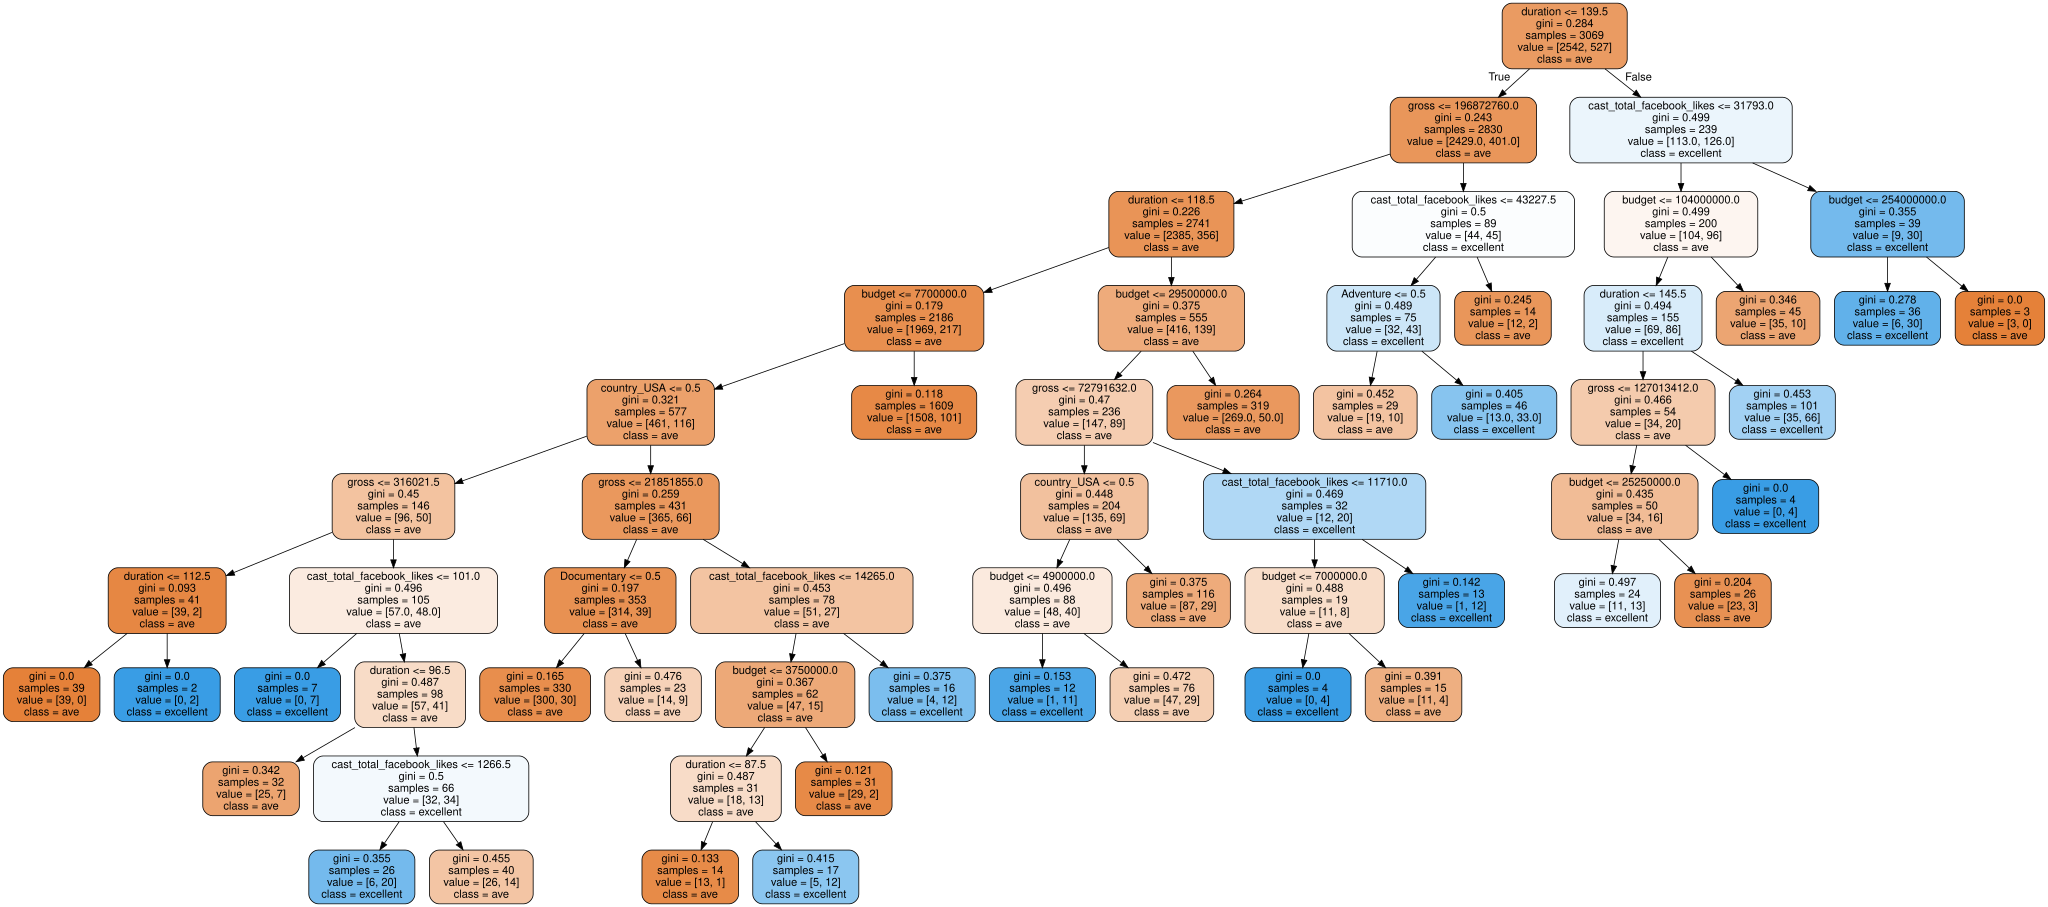

In [63]:
dot_data = export_graphviz(best_nodes, out_file =None,
               feature_names =X.columns, #feature names from dataset
               filled=True, 
                rounded=True, 
                class_names = ['ave','excellent']) #classification labels 
               
graph=graphviz.Source(dot_data)
graph

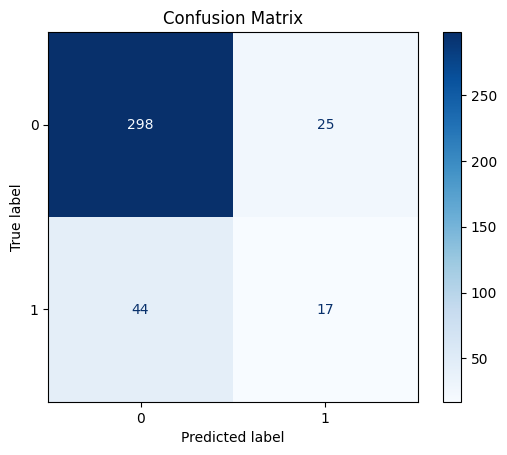

In [73]:
y_pred = model.predict(X_tune)
ConfusionMatrixDisplay.from_estimator(model, X_tune, y_tune, cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [ ]:
TPR = metrics.recall_score(y_tune, model.predict(X_tune))
print("True Positive Rate: ",TPR)
Prec = metrics.precision_score(y_tune, model.predict(X_tune))
print("Precision: ",Prec)
Accuracy = metrics.accuracy_score(y_tune, model.predict(X_tune))
print("Accuracy: ",Accuracy)

True Positive Rate:  0.2786885245901639
Precision:  0.40476190476190477
Accuracy:  0.8203125


Based off the true positive rate and precision, the model slightly improved with the new hyperparameter. Precision is better but still notably low

### Step 22: Using the better model, predict the test data and print out the results.

In [ ]:
TPR = metrics.recall_score(y_test, model.predict(X_test))
print("True Positive Rate: ",TPR)
Prec = metrics.precision_score(y_test, model.predict(X_test))
print("Precision: ",Prec)
Accuracy = metrics.accuracy_score(y_test, model.predict(X_test))
print("Accuracy: ",Accuracy)
# pretty similar results for the test set

True Positive Rate:  0.3333333333333333
Precision:  0.45
Accuracy:  0.8489583333333334


### Step 23: Summarize what you learned along the way and make recommendations to your boss on how this could be used moving forward, being careful not to over promise.

I learned:

a) How to implement cross validation and understand how it gives me a better evaluation of the model

b) how to use grid search to test out different hyper parameters and find the one that helps my model perform the best.

c) how to interpret what my model is doing and how I can use the information if gives me (e.g. the probabilities and equating that to top tier movies)

As for reccomendations for my boss, I would say this model still needs some work before implementation. It's good at identifying average movies, but if our goal is to pick out excellent movies, our model is not doing well. The first thing I would do to address this is change (lower) the threshold for classification as an excellent movie. Additionally, several variables could be removed to help limit noise in the model. When using this model, you need to be aware that the model is missing a good amount of excellent movies from the ones it is identifying.